In [1]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import tensorflow as tf

In [4]:
import numpy as np
import matplotlib.pyplot as plt


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [6]:
train_path = r"C:\Users\tange\Downloads\CODTECH\.ipynb_checkpoints\TASK2-DEEP LEARNING PROJECT\Training"
test_path = r"C:\Users\tange\Downloads\CODTECH\.ipynb_checkpoints\TASK2-DEEP LEARNING PROJECT\Testing"


train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    validation_split=0.2
)


train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)


val_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.


In [7]:
import os
print(os.getcwd())

C:\Users\tange


In [8]:
os.listdir()

['.anaconda',
 '.aws',
 '.azure',
 '.bash_history',
 '.c',
 '.cache',
 '.cagent',
 '.conda',
 '.config',
 '.continuum',
 '.docker',
 '.eclipse',
 '.git',
 '.gitconfig',
 '.groovy',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jdks',
 '.jenkins',
 '.jupyter',
 '.keras',
 '.kube',
 '.lesshst',
 '.local',
 '.m2',
 '.matplotlib',
 '.minikube',
 '.node_repl_history',
 '.npmrc',
 '.p2',
 '.packettracer',
 '.streamlit',
 '.th-client',
 '.VirtualBox',
 '.vscode',
 '.vscode-shared',
 'anaconda3',
 'app',
 'AppData',
 'Application Data',
 'bugfix.txt',
 'Car_sales.csv',
 'Cisco Packet Tracer 8.2.2',
 'configuration-Office365-x64.xml',
 'Contacts',
 'Cookies',
 'Dockerfile',
 'Documents',
 'Downloads',
 'eclipse',
 'eclipse-workspace',
 'exam-docker',
 'Favorites',
 'feature.txt',
 'flask_app',
 'flipkartdatset.ipynb',
 'generator',
 'gitp',
 'hello',
 'hotfix.txt',
 'IntelGraphicsProfiles',
 'jp',
 'lab',
 'lab2.ipynb',
 'Links',
 'Local Settings',
 'major.txt',
 'mcq',
 'mcqgen',
 'Micros

In [9]:
model = tf.keras.Sequential([

tf.keras.layers.Input(shape=(224,224,3)),

tf.keras.layers.Conv2D(
32,
(3,3),
activation='relu'
),

tf.keras.layers.MaxPooling2D(),

tf.keras.layers.Conv2D(
64,
(3,3),
activation='relu'
),

tf.keras.layers.MaxPooling2D(),

tf.keras.layers.Conv2D(
128,
(3,3),
activation='relu'
),

tf.keras.layers.MaxPooling2D(),

tf.keras.layers.Flatten(),

tf.keras.layers.Dense(
128,
activation='relu'
),

tf.keras.layers.Dropout(0.5),

tf.keras.layers.Dense(
4,
activation='softmax'
)

])

In [10]:
model.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy']
)

In [11]:
history = model.fit(
train_data,
validation_data=val_data,
epochs=20
)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 334s 2s/step - accuracy: 0.5585 - loss: 1.0157 - val_accuracy: 0.6982 - val_loss: 0.7444
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 3452s 25s/step - accuracy: 0.7129 - loss: 0.7142 - val_accuracy: 0.7661 - val_loss: 0.5695
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 50582s 363s/step - accuracy: 0.7636 - loss: 0.5867 - val_accuracy: 0.7616 - val_loss: 0.5792
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.7804 - loss: 0.5499 - val_accuracy: 0.8143 - val_loss: 0.4561
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.8118 - loss: 0.4968 - val_accuracy: 0.7964 - val_loss: 0.4997
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.8232 - loss: 0.4554 - val_accuracy: 0.8384 - val_loss: 0.4038
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.8373 - loss: 0.4302 - val_accuracy: 0.8304 - val_loss: 0.4341
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.8502 - loss: 0.3901 - va

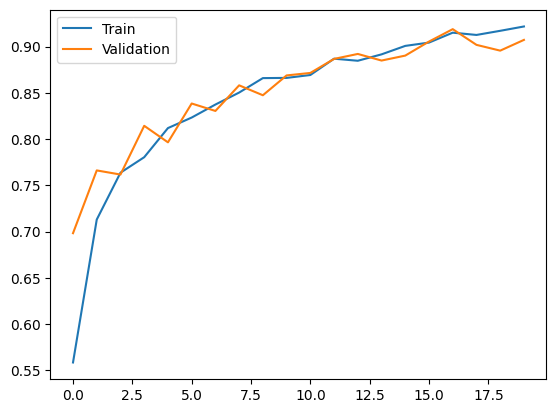

In [12]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(["Train","Validation"])
plt.show()

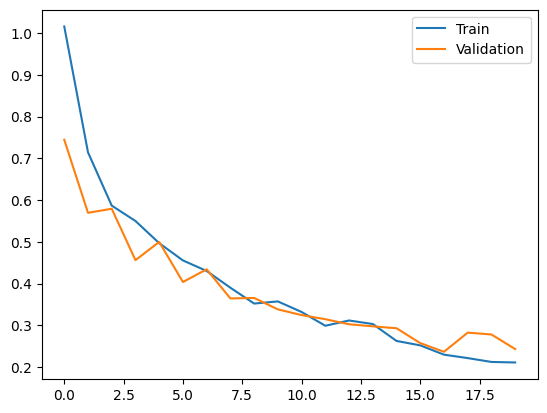

In [13]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend(["Train","Validation"])
plt.show()

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [15]:
model.save("brain_tumor_classifier.h5")